# Assignment 1 — Netflix Trends

**Problem Statement:** Seeing how the number of titles added to Netflix changed over time (by year). Also observing which countries (or genres/listed in categories) contribute the most titles, and how has that changed over time?

**Reproducibility rule:** `Kernel → Restart & Run All` should work without errors.

**Workflow:** Imports → Data creation → Checks → Visuals → Interpretation.

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# loading dataset 
DATA_PATH = "../data/netflix_titles.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Data Dictionary
- **show_id** - unique identifier for each title
- **type** - Movie or TV show
- **title** - name of the show or movie
- **director** - name of the director
- **cast** - names of the actors
- **country** - country where it was made
- **date_added** - the date when the movie was added
- **release_year** - year when it was released
- **rating** - minimum age category to watch the title
- **duration** - runtime of the show or movie
- **listed_in** - genre it is listed in
- **description** - breif overview of what is in the show

### Data Cleaning

In [3]:
# Checking for Duplicates and removing if any
if df[df.duplicated()].size != 0:
    df = df.drop_duplicates()

In [4]:
# checking number of NAs
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
# fixing datatypes
df["date_added"] = pd.to_datetime(df["date_added"])
df["release_year"] = df["release_year"].astype(int)

In [6]:
# checking if type column has only Movie and TV show as values
df["type"].value_counts()

Movie      6131
TV Show    2676
Name: type, dtype: int64

### Data Checks

In [7]:
df.shape

(8807, 12)

In [8]:
df.describe().round(2)

,release_year
count,8807.00
mean,2014.18
std,8.82
min,1925.00
25%,2013.00
50%,2017.00
75%,2019.00
max,2021.00


## Grouped Summary:
Summary stats by a categorical feature

In [9]:
df.groupby("type")["release_year"].agg(["sum", "min", "max"])

,sum,min,max
type,,,
Movie,12342448,1942,2021
TV Show,5396437,1925,2021


## Identifying Outliers
Checking to see what durations of movies and TV shows are shorter or longer than usual

## Comparison of TV shows and Movies added to Netflix per year

In [ ]:
# takes the dataframe as input and returns a table showing how many Movies, TV Shows, and total titles were added to Netflix each year.

def titles_added_per_year(dataframe):
    dataframe["year_added"] = dataframe["date_added"].dt.year
    summary = (
        dataframe
        .dropna(subset=["year_added"])   # dropping NA in year_added column
        .groupby(["year_added", "type"])   # grouping by year_added
        .size()
        .unstack(fill_value=0)
    )

    summary["Total"] = summary.sum(axis=1) # adding total released

    return summary

In [ ]:
titlesAddedPerYear = titles_added_per_year(df)
titlesAddedPerYear

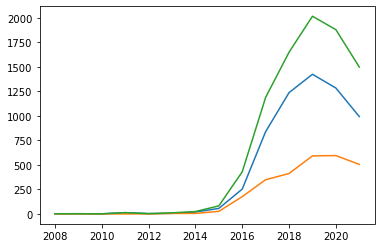

In [17]:
plt.plot(titlesAddedPerYear)